### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


## Imports & Reading the CSV

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd

df = pd.read_csv("grades_crpt.csv")

## Exploring the Dataset

In [6]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005


Seems like there are definitely a bunch of missing (NaN) values.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     object 
dtypes: float64(8), object(1)
memory usage: 6.2+ KB


Only the final exam has an entry for each student (total 86 students).

In [10]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


Doesn't quite make sense to have negative values in these assignments. Only A2, A4, and A6 should have any percentages above 100%.

In [12]:
# Entries with any negative value (using lt)
negative = df[['A1','A2','A3','A4','A5','A6','A7','Final_Exam']].lt(0).any(axis=1)
print(df[negative])

       A1     A2     A3     A4     A5     A6     A7  Final_Exam user_id
9   129.9   76.8   -5.3   93.8  100.0   90.0   12.2        65.3    U010
12   54.2   92.9  -69.3   81.2    NaN  183.6   82.5        71.9    U013
26    NaN    NaN   -1.7   88.8   55.0   20.0   77.5        33.1    U027
44   -4.5  148.9  100.0   98.8   92.0    NaN   91.5        82.5    U045
52   41.7   58.9  -70.1   88.8   80.0   70.0   71.9        31.9    U053
67   90.0  100.0   83.0  -21.6   97.0  100.0   81.2        67.5    U068
76   83.3   64.3   55.0   78.8  100.0  -17.0   78.8        70.9    U077
82   87.5  -30.6   70.0  174.8   91.0    NaN  146.4        64.1    U083


Checking what these negative values might mean; might be an input error? Will probably just make these positive.

In [14]:
# Entries with any value above 100 (using gt)
over100 = df[['A1','A2','A3','A4','A5','A6','A7','Final_Exam']].gt(100).any(axis=1)
print(df[over100])

       A1     A2     A3     A4     A5     A6     A7  Final_Exam user_id
5   100.0   92.9  100.0   96.2    NaN   80.0  110.5        97.5    U006
6    95.8   64.3   63.0  175.8   85.0   76.0   83.8        64.4    U007
7   168.9  100.0   40.0   95.0  100.0  100.0    NaN        40.6    U008
9   129.9   76.8   -5.3   93.8  100.0   90.0   12.2        65.3    U010
12   54.2   92.9  -69.3   81.2    NaN  183.6   82.5        71.9    U013
14   79.2  100.0  100.0   86.2    NaN   60.0  142.1        80.0    U015
15  168.1   64.3    NaN   87.5   90.0   80.0   75.0        46.6    U016
16  174.6   57.1  149.2   87.5    NaN   70.0   80.0        65.3    U017
17    NaN   91.1    NaN  101.2   98.0  100.0   85.6        68.8    U018
21   79.2  114.3   95.0   90.0   95.0    NaN   90.0        64.1    U022
24  130.7    NaN   85.0  188.2  100.0   80.0   85.0        68.8    U025
28    NaN   60.7    NaN  133.8  100.0   90.0   87.5        50.0    U029
30   83.3  100.0   60.0  183.1   90.0   70.0   78.8        49.1 

Checking the entries that might have anything over 100%. Only A2, A4, and A6 really make sense to have anything over 100%.

## Check the correlations

In [17]:
# Selects which columns to show
numeric_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']

# The correlation matrix
corr_matrix = df[numeric_cols].corr()
print(corr_matrix.round(2))

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00 -0.14  0.36  0.30  0.24  0.23 -0.02        0.21
A2         -0.14  1.00  0.21 -0.03  0.01  0.36  0.03        0.28
A3          0.36  0.21  1.00  0.19  0.19 -0.03  0.15        0.28
A4          0.30 -0.03  0.19  1.00  0.04  0.15  0.22        0.40
A5          0.24  0.01  0.19  0.04  1.00  0.24  0.03        0.02
A6          0.23  0.36 -0.03  0.15  0.24  1.00  0.15        0.25
A7         -0.02  0.03  0.15  0.22  0.03  0.15  1.00        0.38
Final_Exam  0.21  0.28  0.28  0.40  0.02  0.25  0.38        1.00


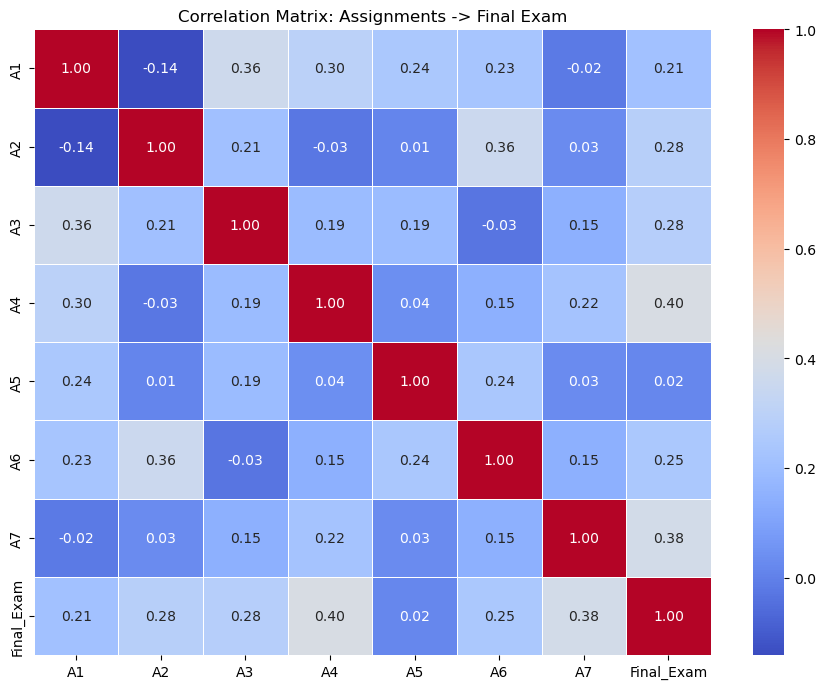

In [18]:
# Heatmap using pyplot
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Assignments -> Final Exam")
plt.tight_layout()
plt.show()

No test strongly correlates with the final exam. The closest ones are A4 and A7 with 0.40 and 0.38 respectively. If I were to choose which ones to predict the final grades with two assignments, it would be **A4 and A7**. Here are my reasons why:

- High correlation values (0.40 & 0.38 respectively)
- Has the most non-null values (77 & 76 respectively)

In [20]:
zero_finalexam = df[['Final_Exam']].eq(0).any(axis=1)
print(df[zero_finalexam])

     A1    A2    A3   A4    A5    A6   A7  Final_Exam user_id
3  25.0  78.6  40.0  0.0  50.0  30.7  0.0         0.0    U004
4   0.0   NaN   0.0  0.0   NaN   NaN  NaN         0.0    U005


Just double checking that there wasn't any funny business with final exams that had 0 as the score. Had one entry each but I don't think it matters all that much. I'm just wondering why U005 even attended this class if they didn't care lol.

## Check for missing values

In [23]:
assignment_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7']

missing_values = df[df[assignment_cols].isnull().any(axis=1)]
print(f"{len(missing_values)} with missing values")
missing_values[['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'user_id']]

73 with missing values


,A1,A2,A3,A4,A5,A6,A7,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,U003
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,U005
5,100.0,92.9,100.0,96.2,NaN,80.0,110.5,U006
...,...,...,...,...,...,...,...,...
81,NaN,NaN,NaN,56.2,NaN,29.2,60.0,U082
82,87.5,-30.6,70.0,174.8,91.0,NaN,146.4,U083
83,79.2,NaN,60.0,27.5,50.0,60.0,75.0,U084
84,NaN,0.0,85.0,100.0,55.0,0.0,0.0,U085


In [24]:
# Count of missing values for each column
print(df.isnull().sum())

A1            29
A2            25
A3            24
A4             9
A5            25
A6            19
A7            10
Final_Exam     0
user_id        0
dtype: int64


All assignment columns have missing values (NaN), and there are a total of 73 entries with them. Above is a list of missing values for each assignment, with A1 having the most at 29.

## Handle the missing values

In [27]:
# Separate copies for mean, median, and drop
df_mean_replaced = df.copy()
df_median_replaced = df.copy()
df_dropped = df.dropna(subset=['A1','A2','A3','A4','A5','A6','A7'])

# Mean imputation
df_mean_replaced[assignment_cols] = df_mean_replaced[assignment_cols].fillna(df_mean_replaced[assignment_cols].mean())

# Median imputation
df_median_replaced[assignment_cols] = df_median_replaced[assignment_cols].fillna(df_median_replaced[assignment_cols].median())

print(f"Original rows:   {len(df)}")
print(f"After dropping:  {len(df_dropped)}")

Original rows:   86
After dropping:  13


I feel that the median would work the best because I haven't even cleaned the data yet. We have negative values and values over 100 for non-bonus assignments that skew the mean. There are way too many null values to drop. Median is the lesser of three evils. So I think that one gives the better results.

In [29]:
# Compare correlation with Final_Exam under each strategy
for label, frame in [('Mean', df_mean_replaced), ('Median', df_median_replaced), ('Dropped', df_dropped)]: # Iterates through the three
    corr = frame[assignment_cols + ['Final_Exam']].corr()['Final_Exam'] # Gets the correlation with the Final_Exam column
    print(f"\n{label}")
    print(corr.round(3))


Mean
A1            0.181
A2            0.237
A3            0.247
A4            0.380
A5            0.015
A6            0.208
A7            0.350
Final_Exam    1.000
Name: Final_Exam, dtype: float64

Median
A1            0.178
A2            0.222
A3            0.255
A4            0.389
A5            0.019
A6            0.207
A7            0.348
Final_Exam    1.000
Name: Final_Exam, dtype: float64

Dropped
A1            0.786
A2            0.294
A3            0.424
A4            0.336
A5            0.139
A6            0.338
A7            0.169
Final_Exam    1.000
Name: Final_Exam, dtype: float64


This is what I came up with to evaluate my results: check the correlation to see if it matches up with the Final_Exam better. Surprisingly, the mean matched up with the Final_Exam scores more in general. Let me clean the data and try again after. I'm sure there's another strategy to check if the distribution of the data remains roughly the same, but 1) ~~I don't want to figure out how to do that right now~~ and 2) I don't think 86 entries are enough to have any decent distribution to compare hehe

## Check for outliers

Ok here's my plan because we already somewhat explored the dataset:
1. For the values above 100% in assignments 1, 3, 5, and 7
    - I'm assuming they're data entry mistakes, because they can't even get bonus marks for these. So I'll subtract 100 from them.
2. For the values above 100% in assignments 2, 4, and 6
    - I'll keep these because we weren't given the right base point for each assignment (because the points are not in percentages like the brief said)
3. Negative values
    - I will also assume these are data entry errors, and will just flip them to be positive. I like to live in a world where no teacher is ruthless enough to award a negative grade for an assignment :sob:

In [33]:
df_cleaned = df.copy()

# Subtract 100
no_bonus_cols = ['A1', 'A3', 'A5', 'A7']
for col in no_bonus_cols:
    mask = df_cleaned[col] > 100
    df_cleaned.loc[mask, col] = df_cleaned.loc[mask, col] - 100
    print(f"{col}: {mask.sum()} values corrected (subtracted 100)")
    
# Flip values using abs()
for col in assignment_cols:
    mask = df_cleaned[col] < 0
    df_cleaned.loc[mask, col] = df_cleaned.loc[mask, col].abs()
    print(f"{col}: {mask.sum()} negative values flipped")

A1: 5 values corrected (subtracted 100)
A3: 3 values corrected (subtracted 100)
A5: 5 values corrected (subtracted 100)
A7: 7 values corrected (subtracted 100)
A1: 1 negative values flipped
A2: 1 negative values flipped
A3: 4 negative values flipped
A4: 1 negative values flipped
A5: 0 negative values flipped
A6: 1 negative values flipped
A7: 0 negative values flipped


In [34]:
# Before & after
print("\nBefore")
print(df[assignment_cols].describe().round(2))

print("\nAfter")
print(df_cleaned[assignment_cols].describe().round(2))


Before
           A1      A2      A3      A4      A5      A6      A7
count   57.00   61.00   62.00   77.00   61.00   67.00   76.00
mean    83.67   81.10   68.17   82.33   89.65   74.44   78.13
std     34.29   28.56   42.34   39.10   25.51   31.18   26.41
min     -4.50  -30.60  -70.10  -21.60    7.70  -17.00    0.00
25%     75.80   64.30   50.00   72.00   87.00   60.00   70.30
50%     87.50   91.10   80.00   87.50   95.00   80.00   80.00
75%     95.80  100.00   93.25   95.00  100.00   92.50   87.50
max    174.60  148.90  152.20  188.20  173.90  183.60  150.60

After
           A1      A2      A3      A4      A5      A6     A7
count   57.00   61.00   62.00   77.00   61.00   67.00  76.00
mean    75.06   82.10   68.06   82.89   81.45   74.94  68.92
std     26.50   25.48   28.60   37.88   23.84   29.92  24.07
min      0.00    0.00    0.00    0.00    7.70    0.00   0.00
25%     70.80   64.30   50.20   72.00   73.90   60.00  59.38
50%     83.30   91.10   78.00   87.50   90.00   80.00  77.50


In [35]:
# Check correlation
print("Cleaned")
corr = df_cleaned[assignment_cols + ['Final_Exam']].corr()['Final_Exam'] # Gets the correlation with the Final_Exam column
print(corr.round(3))

print("Original")
corr = df[assignment_cols + ['Final_Exam']].corr()['Final_Exam'] # Gets the correlation with the Final_Exam column
print(corr.round(3))

Cleaned
A1            0.261
A2            0.337
A3            0.292
A4            0.427
A5            0.202
A6            0.272
A7            0.099
Final_Exam    1.000
Name: Final_Exam, dtype: float64
Original
A1            0.213
A2            0.285
A3            0.278
A4            0.403
A5            0.018
A6            0.246
A7            0.381
Final_Exam    1.000
Name: Final_Exam, dtype: float64


A7 got much worse... Now what I would choose are A4 and A2 to predict the final exam score. If you recall the initial check of values over 100, A7 did have quite a bit. From the original, A2 would've been third on the list anyway.

## Handle missing values again

In [38]:
# Separate CLEAN copies for mean, median, and drop
df_mean_replaced_cleaned = df_cleaned.copy()
df_median_replaced_cleaned = df_cleaned.copy()

# Mean imputation
df_mean_replaced_cleaned[assignment_cols] = df_mean_replaced_cleaned[assignment_cols].fillna(df_mean_replaced_cleaned[assignment_cols].mean())

# Median imputation
df_median_replaced_cleaned[assignment_cols] = df_median_replaced_cleaned[assignment_cols].fillna(df_median_replaced_cleaned[assignment_cols].median())

# Compare correlation with Final_Exam under each strategy
for label, frame in [('Mean Clean', df_mean_replaced_cleaned), ('Median Clean', df_median_replaced_cleaned)]: # Iterates through the two
    corr = frame[assignment_cols + ['Final_Exam']].corr()['Final_Exam'] # Gets the correlation with the Final_Exam column
    print(f"\n{label}")
    print(corr.round(3))


Mean Clean
A1            0.222
A2            0.280
A3            0.259
A4            0.403
A5            0.164
A6            0.230
A7            0.091
Final_Exam    1.000
Name: Final_Exam, dtype: float64

Median Clean
A1            0.211
A2            0.265
A3            0.268
A4            0.411
A5            0.168
A6            0.229
A7            0.083
Final_Exam    1.000
Name: Final_Exam, dtype: float64


Hey at least A4 looks better... I may have gotten lost in the sauce.

The average still looks much better than the median one for some reason. 